In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch, gpytorch, os, time
from sklearn.preprocessing import StandardScaler
import numpy as np
import calendar

from gpytorch.models import ApproximateGP
from gpytorch.variational import (
    CholeskyVariationalDistribution,
    VariationalStrategy,
    LMCVariationalStrategy,
    MultitaskVariationalStrategy
)
from gpytorch.mlls.variational_elbo import VariationalELBO
from gpytorch.kernels import RBFKernel, ScaleKernel, MultitaskKernel
from gpytorch.likelihoods import MultitaskGaussianLikelihood, GaussianLikelihood
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import KFold

from utils import load_and_merge_weather_data, load_supply_data, load_installed_cap_data, get_time_intersection

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device: {device}')

RANDOM_SEED = 42

data_folder = 'data'
weather_data_fpaths = [os.path.join(data_folder, weather_file)for weather_file in ['Weather_Data_Germany.csv', 'Weather_Data_Germany_2022.csv']]
supply_data_fpath = os.path.join(data_folder, 'Realised_Supply_Germany.csv')
cap_data_fpath = os.path.join(data_folder, 'Installed_Capacity_Germany.csv')

using device: cpu


# Loading the Data and Preprocessing

In [3]:
weather_df = load_and_merge_weather_data(weather_data_fpaths)

weather_df.iloc[[0, 1, 23, 24, 25, -2, -1]]

,time,cdir,z,msl,blh,tcc,u10,v10,t2m,ssr,tsr,sund,tp,fsr,u100,v100
0,2019-01-01 00:00:00+00:00,0.000,3360.296561,103009.967750,507.635043,0.966562,3.867164,1.065368,278.216013,0.000000e+00,0.000,0.000000,0.000000e+00,0.741971,6.545994,1.122055
1,2019-01-01 01:00:00+00:00,0.000,3360.296561,102964.489612,544.627164,0.959348,4.092345,1.116217,278.310794,0.000000e+00,0.000,0.000000,3.803349e-05,0.742205,6.838839,1.241379
23,2019-01-01 23:00:00+00:00,3066853.275,3360.296561,102310.656087,1282.185074,0.628171,5.543300,-4.233978,276.084614,1.617137e+06,3531474.625,9901.251962,1.907228e-03,0.742104,8.717265,-6.877415
24,2019-01-02 00:00:00+00:00,0.000,3360.296561,102431.760900,1190.333533,0.660718,5.078227,-4.134211,275.615555,0.000000e+00,0.000,-0.007812,7.450581e-09,0.741824,8.010838,-6.809227
25,2019-01-02 01:00:00+00:00,0.000,3360.296561,102462.246775,1234.541036,0.598510,4.837781,-4.484831,275.565373,0.000000e+00,0.000,-0.007812,1.602382e-04,0.742285,7.592956,-7.328369
35062,2022-12-31 22:00:00+00:00,3010416.425,3360.300465,101413.335688,855.964935,0.824257,4.053605,4.901148,284.452551,2.210629e+06,4074921.825,11443.273025,5.087158e-03,0.745430,7.320207,8.137603
35063,2022-12-31 23:00:00+00:00,3010416.425,3360.300465,101444.050062,844.058690,0.809066,4.008353,4.860213,284.285022,2.210669e+06,4074921.825,11443.273025,5.100906e-03,0.745408,7.251386,8.022535


In [4]:
supply_hourly = load_supply_data(supply_data_fpath)
supply_hourly

,time,solar_supply_sum,solar_supply_mean
0,2019-01-01 00:00:00+00:00,0.0,0.0
1,2019-01-01 01:00:00+00:00,0.0,0.0
2,2019-01-01 02:00:00+00:00,0.0,0.0
3,2019-01-01 03:00:00+00:00,0.0,0.0
4,2019-01-01 04:00:00+00:00,0.0,0.0
...,...,...,...
35055,2022-12-31 19:00:00+00:00,0.0,0.0
35056,2022-12-31 20:00:00+00:00,0.0,0.0
35057,2022-12-31 21:00:00+00:00,0.0,0.0
35058,2022-12-31 22:00:00+00:00,0.0,0.0


2019-01-01 00:00:00+00:00    44036.0
2023-01-01 00:00:00+00:00    57744.0
Freq: 35064h, Name: Photovoltaic [MW], dtype: float64


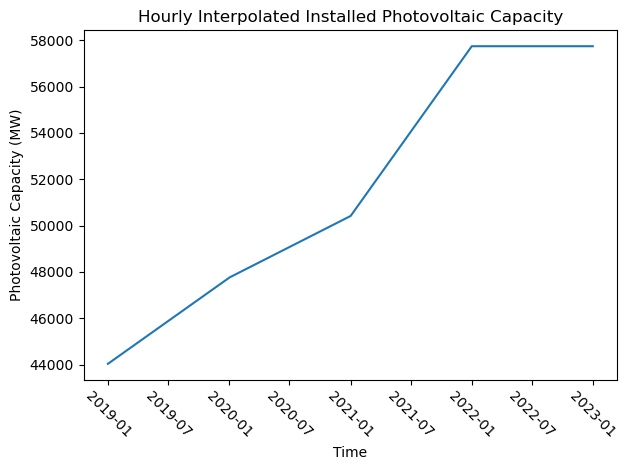

In [3]:
capacity_df = load_installed_cap_data(cap_data_fpath)
# capacity_df
print(capacity_df.iloc[[0, -1]])

plt.figure()
plt.plot(capacity_df.index, capacity_df.values)
plt.xlabel('Time')
plt.ylabel('Photovoltaic Capacity (MW)')
plt.title('Hourly Interpolated Installed Photovoltaic Capacity')
plt.xticks(rotation=-45)
plt.tight_layout()
plt.show()



### Combine the tree tables based on the intersection of dates present
Only use the data points from dates which are included in all datasets

In [8]:
print(f"Supply data ranges from {supply_hourly['time'].min()} to {supply_hourly['time'].max()}")
print(f"Weather data ranges from {weather_df['time'].min()} to {weather_df['time'].max()}")
print(f"Installed capacity ranges from {capacity_df['Date from'].min()} to {capacity_df['Date to'].max()}")
common_time_idx = get_time_intersection(weather_df, supply_hourly, capacity_df)

NameError: name 'supply_hourly' is not defined

In [10]:
def prepare_next_day_forecast(data, target_col='solar_supply', forecast_horizon=24):
    """
    X[i] = all features at time-step i
    y[i] = target_col values for the next `forecast_horizon` hours (i+1 ... i+forecast_horizon)
    """
    X, y = [], []
    n = len(data)
    for i in range(n - forecast_horizon):
        # Input: all columns at time i
        X.append(data.iloc[i].values)
        # Output: solar_supply at next 24 hours
        y.append(data[target_col].iloc[i+1 : i+1+forecast_horizon].values)
    return np.vstack(X), np.vstack(y)

In [11]:
# 1) Align each table on the common_time_idx
weather_aligned = (
    weather_df
    .set_index('time')
    .reindex(common_time_idx)
    .interpolate(method='time')
    .ffill()
)

supply_aligned = (
    supply_hourly
    .set_index('time')
    .reindex(common_time_idx)
    .interpolate(method='time')
)

capacity_aligned = (
    cap_hourly
    .reindex(common_time_idx)
    .interpolate(method='time')
)

# 2) Merge them into one DataFrame
full_data = pd.concat([
    supply_aligned,
    weather_aligned,
    capacity_aligned.rename('Installed_Capacity')
], axis=1)

# 3) Sanity‐check
# print('Any NaNs left? ', df.isna().any().any())

# Chose the target column. This is either the sum or mean of the solar supply per hour. Drop the other one
target_col = 'solar_supply_sum'  # or 'solar_supply_mean'
drop_target = 'solar_supply_mean' if target_col == 'solar_supply_sum' else 'solar_supply_sum'
full_data.drop(columns=[drop_target], inplace=True)
full_data.rename(columns={target_col: 'solar_supply'}, inplace=True)

In [12]:
hour_norm = 2 * np.pi * full_data.index.hour / 24
full_data['hour_sin'] = np.sin(hour_norm)
full_data['hour_cos'] = np.cos(hour_norm)

years = full_data.index.year
days_in_year = np.where([calendar.isleap(y) for y in years], 366, 365) # this accounts the sine/cos wave for leap years
day_of_year_ang = 2 * np.pi * (full_data.index.dayofyear - 1) / days_in_year
full_data['day_of_year_sin'] = np.sin(day_of_year_ang)
full_data['day_of_year_cos'] = np.cos(day_of_year_ang)

In [13]:
data_cols = full_data.columns

full_data

,solar_supply,cdir,z,msl,blh,tcc,u10,v10,t2m,ssr,...,sund,tp,fsr,u100,v100,Installed_Capacity,hour_sin,hour_cos,day_of_year_sin,day_of_year_cos
2019-01-01 00:00:00+00:00,0.0,0.000,3360.296561,103009.967750,507.635043,0.966562,3.867164,1.065368,278.216013,0.0,...,0.000000,0.000000,0.741971,6.545994,1.122055,44036.000000,0.000000,1.000000,0.000000,1.000000
2019-01-01 01:00:00+00:00,0.0,0.000,3360.296561,102964.489612,544.627164,0.959348,4.092345,1.116217,278.310794,0.0,...,0.000000,0.000038,0.742205,6.838839,1.241379,44036.424429,0.258819,0.965926,0.000000,1.000000
2019-01-01 02:00:00+00:00,0.0,0.000,3360.296561,102908.208325,575.103757,0.966846,4.320050,1.223478,278.206292,0.0,...,0.000000,0.000070,0.742254,7.183921,1.428783,44036.848858,0.500000,0.866025,0.000000,1.000000
2019-01-01 03:00:00+00:00,0.0,0.000,3360.296561,102827.034387,612.314609,0.979125,4.638074,1.222571,278.140331,0.0,...,0.000000,0.000099,0.742272,7.660834,1.501984,44037.273288,0.707107,0.707107,0.000000,1.000000
2019-01-01 04:00:00+00:00,0.0,0.000,3360.296561,102725.913987,660.112603,0.981526,4.980449,1.055763,278.102989,0.0,...,0.000000,0.000135,0.742255,8.147790,1.289936,44037.697717,0.866025,0.500000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 19:00:00+00:00,0.0,3129008.475,3360.296561,101976.098625,556.613340,0.722443,4.856750,1.199851,282.137201,2401033.1,...,13001.552051,0.002120,0.744008,8.698027,1.518263,57739.813927,-0.965926,0.258819,-0.017213,0.999852
2021-12-31 20:00:00+00:00,0.0,3129008.475,3360.296561,102033.841887,554.070623,0.742826,4.847286,1.136856,282.006911,2401033.1,...,13001.552051,0.002178,0.744012,8.648112,1.437886,57740.651142,-0.866025,0.500000,-0.017213,0.999852
2021-12-31 21:00:00+00:00,0.0,3129008.475,3360.296561,102091.653488,563.626273,0.774830,4.865667,1.038958,281.939356,2401033.1,...,13001.552051,0.002234,0.744066,8.608811,1.275468,57741.488356,-0.707107,0.707107,-0.017213,0.999852
2021-12-31 22:00:00+00:00,0.0,3129018.675,3360.296561,102147.443737,564.532256,0.789304,4.747809,0.969694,281.810604,2401033.1,...,13001.552051,0.002267,0.744047,8.410140,1.149305,57742.325571,-0.500000,0.866025,-0.017213,0.999852


### Preprocessing

This involves splitting the data into train/test and standadization of each input feature to have a mean $\mu=0$ and a standard deviation $\sigma=1$ based on the train data

Each column of the data needs to be standardized **individually**!

$$\operatorname{Standardization: } z=\frac{x-\mu}{\sigma}$$

In [14]:
# 2) Split out the two scalers:
# Identify which columns to scale vs. which ones to keep. -> Keep the time (sin & cos) columns
all_features = full_data.columns.tolist()
time_feats   = ['hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos']
target_col   = 'solar_supply'
#   • target_scaler on all historical solar_supply (before last_year)
#   • feature_scaler on all other columns (before last_year)

feature_cols_to_scale = [c for c in all_features if (c not in time_feats and c != target_col)]
feature_cols_static   = time_feats  # these go straight into X without scaling

# 1) Identify last‐year cutoff
last_year = full_data.index.year.max()
train_idx = full_data.index.year < last_year

feature_scaler = StandardScaler().fit(
    full_data.loc[train_idx, feature_cols_to_scale]
)
target_scaler = StandardScaler().fit(
    full_data.loc[train_idx, ['solar_supply']]
)

# 3) Apply them *in place* to the full_data (so you never lose sync)
full_data_scaled = full_data.copy()
# Scale the continuous features and leave time features untouched
full_data_scaled.loc[:, feature_cols_to_scale] = feature_scaler.transform(full_data_scaled[feature_cols_to_scale])
full_data_scaled['solar_supply'] = target_scaler.transform(
    full_data_scaled[['solar_supply']]
)

In [15]:
def df2t(df):
    """Convert a pd.DataFrame to a torch float tensor on `device`."""
    return torch.from_numpy(df.values).float().to(device)

In [19]:
horizon = 24 # How many hours we want to predict into the future
y_df = pd.concat(
    {f'y+{i}h': full_data_scaled['solar_supply'].shift(-i) for i in range(1, horizon+1)},
    axis=1
).dropna() # Remove the last 24 entries as they contain NaNs

# Ensure only values from the full table are taken for which there are values in the y_df (removes the last 24 entries)
feature_cols = full_data_scaled.columns.tolist()
X_df = full_data_scaled.loc[y_df.index, feature_cols_to_scale + feature_cols_static]

# 3) Train/test split by year
train_mask = X_df.index.year < last_year
X_train, y_train = X_df.loc[train_mask], y_df.loc[train_mask]
X_test,  y_test  = X_df.loc[~train_mask], y_df.loc[~train_mask]

# Convert data to tensors
X_train, y_train, X_test, y_test = map(df2t, (X_train, y_train, X_test, y_test))
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

# Save dates
dates_train = X_df.loc[train_mask].index
dates_test = X_df.loc[~train_mask].index


# Shapes check
print(f'Train data | X: {X_train.shape} y: {y_train.shape}')  # (n_train, n_features), (n_train, 24)
print(f'Test data  | X: {X_test.shape} y: {y_test.shape}')   # (n_test,  n_features), (n_test,  24)

Train data | X: torch.Size([17544, 20]) y: torch.Size([17544, 24])
Test data  | X: torch.Size([8736, 20]) y: torch.Size([8736, 24])


# Model

The exact GP is not suitable as it scales $\mathcal{O}(n^3)$, so we need to use an Approximate GP with a Variational Strategy, e.g. maximizing the Evidence lower-bound (ELBO)

In [20]:
class GPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points, num_tasks, num_latents,
                 mean_module, covar_module):
        """
        inducing_points: Tensor (M, D)
        num_tasks:       # of outputs, here 24
        num_latents:     # of latent GPs to mix (<= num_tasks)
        mean_module:     a gpytorch.means.Mean object, batched [num_latents]
        covar_module:    a gpytorch.kernels.Kernel within ScaleKernel, batched
        """
        # 1) variational distribution for each latent GP
        M = inducing_points.size(0)
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            M, batch_shape=torch.Size([num_latents])
        )
        # 2) single‐task variational strategy, batched
        base_vs = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points.unsqueeze(0).expand(num_latents, M, -1),
            variational_distribution,
            learn_inducing_locations=True
        )
        # 3) mix latents → tasks
        variational_strategy = gpytorch.variational.LMCVariationalStrategy(
            base_vs, num_tasks, num_latents, latent_dim=-1
        )
        super().__init__(variational_strategy)

        # plug in chosen mean & covar modules
        self.mean_module = mean_module
        self.covar_module = covar_module

    def forward(self, x):
        # x: (..., D)
        mean = self.mean_module(x)        # → (num_latents, N)
        covar = self.covar_module(x)      # → (num_latents, N, N)
        return gpytorch.distributions.MultivariateNormal(mean, covar)

# Parameter Search to find the model that fits the data best

Basic method that creates the model, trains it and returns the rmse for the validation set

In [21]:
def train_and_eval(X_tr, y_tr, X_val, y_val,  
                   kernel_builder, mean_builder,
                   num_inducing, num_latents, lr, num_epochs, device):
    # slice inducing points
    inducing = X_tr[:num_inducing].clone()

    # build mean & covar modules (batched over num_latents)
    mean_mod  = mean_builder(num_latents).to(device)
    covar_mod = kernel_builder(num_latents).to(device)

    # instantiate model + likelihood
    model = GPModel(inducing, y_tr.shape[1], num_latents, mean_mod, covar_mod).to(device)
    likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=y_tr.shape[1]).to(device)

    # optim + ELBO
    optimizer = torch.optim.Adam([
        {'params': model.parameters()},
        {'params': likelihood.parameters()}
    ], lr=lr)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=X_tr.size(0))

    model.train()
    likelihood.train()
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        output = model(X_tr)
        loss = -mll(output, y_tr)
        loss.backward()
        optimizer.step()

    # eval
    model.eval(); likelihood.eval()
    with torch.no_grad():
        pred = likelihood(model(X_val)).mean.cpu()
    rmse = torch.sqrt(((pred - y_val.cpu())**2).mean()).item()
    return rmse

Define the search space for our grid-search: Number of inducing points, latent dimension, learning rates, epochs, mean kernels and covariance kernels

In [22]:
# Search Space definition: Model hyperparameters (inducing points, latents, mean kernels, covariance kernels), training hyperparameters (epochs, learning_rates)
# (you can of course tweak these lists)
inducing_list = [200, 500, 1000]
latents_list  = [3, 6, 12, 24]
lr_list       = [1e-2, 5*1e-3, 1e-3]
epochs_list   = [100, 250, 500]
# TODO: LOSS FUNCTIONS?

# kernel choices (each must accept num_latents → batched module)
kernel_builders = {
    'RBF'        : lambda L: gpytorch.kernels.ScaleKernel(
                         gpytorch.kernels.RBFKernel(batch_shape=torch.Size([L])),
                         batch_shape=[L]),
    'Matern32_nu_2_5'   : lambda L: gpytorch.kernels.ScaleKernel(
                         gpytorch.kernels.MaternKernel(nu=2.5,
                             batch_shape=[L]),
                         batch_shape=[L]),
    'Matern32_nu_1_5'   : lambda L: gpytorch.kernels.ScaleKernel(
                         gpytorch.kernels.MaternKernel(nu=1.5,
                             batch_shape=[L]),
                         batch_shape=[L]),
    'Periodic'   : lambda L: gpytorch.kernels.ScaleKernel(
                         gpytorch.kernels.PeriodicKernel(batch_shape=[L]),
                         batch_shape=[L]),
    'SpectralMixture': lambda L: gpytorch.kernels.ScaleKernel(
        gpytorch.kernels.SpectralMixtureKernel(num_mixtures=4, batch_shape=torch.Size([L]))), 
    'RBF+Periodic': lambda L: gpytorch.kernels.ScaleKernel(
                         gpytorch.kernels.RBFKernel(batch_shape=torch.Size([L]))
                         + gpytorch.kernels.PeriodicKernel(batch_shape=[L]),
                         batch_shape=[L]),
    'RBFxPeriodic': lambda L: gpytorch.kernels.ScaleKernel(
                         gpytorch.kernels.RBFKernel(batch_shape=torch.Size([L]))
                         * gpytorch.kernels.PeriodicKernel(batch_shape=[L]),
                         batch_shape=[L]),
}

# mean choices
mean_builders = {
    'Constant'  : lambda L: gpytorch.means.ConstantMean(
                          batch_shape=torch.Size([L])),
    'Zero'      : lambda L: gpytorch.means.ZeroMean(
                          batch_shape=[L]),
    'Linear'    : lambda L: gpytorch.means.LinearMean(
                          input_size=X_train.shape[1],
                          batch_shape=[L]),
}

In [26]:
# Search Space definition: Model hyperparameters (inducing points, latents, mean kernels, covariance kernels), training hyperparameters (epochs, learning_rates)
# (you can of course tweak these lists)
inducing_list = [200]
latents_list  = [3, 6]
lr_list       = [1e-2, 5*1e-3, 1e-3]
epochs_list   = [1, 2]

# kernel choices (each must accept num_latents → batched module)
kernel_builders = {
    'RBF'        : lambda L: gpytorch.kernels.ScaleKernel(
                         gpytorch.kernels.RBFKernel(batch_shape=torch.Size([L])),
                         batch_shape=[L]),
    'Matern32_nu_2_5'   : lambda L: gpytorch.kernels.ScaleKernel(
                         gpytorch.kernels.MaternKernel(nu=2.5, batch_shape=[L]),
                         batch_shape=[L]),
}

# mean choices
mean_builders = {
    'Linear'    : lambda L: gpytorch.means.LinearMean(
                          input_size=X_train.shape[1],
                          batch_shape=[L]),
}

Validate with 5-Fold-Cross-Validation

In [27]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
best = {'rmse': float('inf')}

total_it = len(kernel_builders) * len(mean_builders) * len(inducing_list) * len(latents_list) * len(lr_list) * len(epochs_list)
curr_iteration = 1
# Grid Search through all parameters
for kernel_name, kbuilder in kernel_builders.items():
    for mean_name, mbuilder in mean_builders.items():
        for num_inducing in inducing_list:
            for num_latents in latents_list:
                for lr in lr_list:
                    for epochs in epochs_list:
                        start_time = time.time()
                        rmses = []
                        for tr_idx, val_idx in kf.split(X_train):
                            X_tr, X_val = X_train[tr_idx], X_train[val_idx]
                            y_tr, y_val = y_train[tr_idx], y_train[val_idx]
                            rmse = train_and_eval(
                                X_tr, y_tr, X_val, y_val,
                                kbuilder, mbuilder,
                                num_inducing, num_latents,
                                lr, epochs, device
                            )
                            rmses.append(rmse)
                        # Average rmse across folds
                        avg_rmse = np.mean(rmses)
                        print(f'{curr_iteration:3d}/{total_it} in {time.time()-start_time:5.2f}s | GP({mean_name}, {kernel_name}) | '
                              f'num_inducing={num_inducing}, num_latents={num_latents}, '
                              f'lr={lr:.4f}, epochs={epochs} → '
                              f'RMSE={avg_rmse:.4f}')
                        curr_iteration += 1
                        if avg_rmse < best['rmse']:
                            best.update({
                                'rmse':      avg_rmse,
                                'kernel':   kernel_name,
                                'mean':     mean_name,
                                'num_inducing': num_inducing,
                                'num_latents':  num_latents,
                                'lr':       lr,
                                'epochs':   epochs
                            })

  1/24 in  6.65s | GP(Linear, RBF) | num_inducing=200, num_latents=3, lr=0.0100, epochs=1 → RMSE=7.4422
  2/24 in 11.43s | GP(Linear, RBF) | num_inducing=200, num_latents=3, lr=0.0100, epochs=2 → RMSE=7.0686
  3/24 in  5.67s | GP(Linear, RBF) | num_inducing=200, num_latents=3, lr=0.0050, epochs=1 → RMSE=6.6111
  4/24 in 12.03s | GP(Linear, RBF) | num_inducing=200, num_latents=3, lr=0.0050, epochs=2 → RMSE=6.7982
  5/24 in  5.56s | GP(Linear, RBF) | num_inducing=200, num_latents=3, lr=0.0010, epochs=1 → RMSE=7.9204
  6/24 in 11.81s | GP(Linear, RBF) | num_inducing=200, num_latents=3, lr=0.0010, epochs=2 → RMSE=7.1430
  7/24 in 10.69s | GP(Linear, RBF) | num_inducing=200, num_latents=6, lr=0.0100, epochs=1 → RMSE=10.0506
  8/24 in 21.91s | GP(Linear, RBF) | num_inducing=200, num_latents=6, lr=0.0100, epochs=2 → RMSE=10.4196
  9/24 in  9.71s | GP(Linear, RBF) | num_inducing=200, num_latents=6, lr=0.0050, epochs=1 → RMSE=10.2967
 10/24 in 48.62s | GP(Linear, RBF) | num_inducing=200, num_la

In [28]:
print('BEST CONFIG:')
for k,v in best.items():
    print(f'  {k:12s} : {v}')



BEST CONFIG:
  rmse         : 6.461760520935059
  kernel       : Matern32_nu_2_5
  mean         : Linear
  num_inducing : 200
  num_latents  : 3
  lr           : 0.01
  epochs       : 2


# Train the full model with the best parameters

In [35]:
num_inducing = best['num_inducing']
inducing_points = X_train[:num_inducing].clone()  # shape: (num_inducing, d)

num_tasks = horizon
num_latents = best['num_latents'] # Compression dimension, max = num_tasks

mean_kernel = mean_builders[best['mean']](num_latents).to(device)
cov_kernel = kernel_builders[best['kernel']](num_latents).to(device)
model = GPModel(inducing_points=inducing_points, num_tasks=y_train.shape[1], num_latents=num_latents, mean_module=mean_kernel, covar_module=cov_kernel).to(device)
likelihood = MultitaskGaussianLikelihood(num_tasks=num_tasks).to(device)

# Variational ELBO
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=X_train.size(0))

# Training mode
model.train()
likelihood.train()

optimizer = torch.optim.Adam(
    [{'params': model.parameters()}, {'params': likelihood.parameters()}],
    lr=best['lr']
)

# --- Training Loop ---
num_epochs = best['epochs']
for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_train)           # now returns a 24-task MVN
    loss = -mll(output, y_train)      # y_train_tensor shape: (N, 24)
    loss.backward()
    print(f'Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.3f}')
    optimizer.step()

Epoch 1/2 - Loss: 382.404
Epoch 2/2 - Loss: 364.409


In [37]:
# TODO: Remove this after testing
num_epochs = best['epochs']
for epoch in range(1000):
    optimizer.zero_grad()
    output = model(X_train)           # now returns a 24-task MVN
    loss = -mll(output, y_train)      # y_train_tensor shape: (N, 24)
    loss.backward()
    print(f'Epoch {epoch+1}/1000 - Loss: {loss.item():.3f}')
    optimizer.step()

Epoch 1/2 - Loss: 315.755
Epoch 2/2 - Loss: 301.240
Epoch 3/2 - Loss: 287.532
Epoch 4/2 - Loss: 274.602
Epoch 5/2 - Loss: 262.420
Epoch 6/2 - Loss: 250.952
Epoch 7/2 - Loss: 240.164
Epoch 8/2 - Loss: 230.023
Epoch 9/2 - Loss: 220.496
Epoch 10/2 - Loss: 211.548
Epoch 11/2 - Loss: 203.146
Epoch 12/2 - Loss: 195.254
Epoch 13/2 - Loss: 187.841
Epoch 14/2 - Loss: 180.874
Epoch 15/2 - Loss: 174.322
Epoch 16/2 - Loss: 168.156
Epoch 17/2 - Loss: 162.348
Epoch 18/2 - Loss: 156.873
Epoch 19/2 - Loss: 151.706
Epoch 20/2 - Loss: 146.826
Epoch 21/2 - Loss: 142.212
Epoch 22/2 - Loss: 137.846
Epoch 23/2 - Loss: 133.712
Epoch 24/2 - Loss: 129.795
Epoch 25/2 - Loss: 126.080
Epoch 26/2 - Loss: 122.556
Epoch 27/2 - Loss: 119.210
Epoch 28/2 - Loss: 116.033
Epoch 29/2 - Loss: 113.014
Epoch 30/2 - Loss: 110.145
Epoch 31/2 - Loss: 107.417
Epoch 32/2 - Loss: 104.822
Epoch 33/2 - Loss: 102.353
Epoch 34/2 - Loss: 100.003
Epoch 35/2 - Loss: 97.765
Epoch 36/2 - Loss: 95.631
Epoch 37/2 - Loss: 93.597
Epoch 38/2 - 

# Benchmarking
See how well the model performs on test data

In [39]:
# 1) Move everything to CPU & eval mode
device_cpu = torch.device('cpu')
model = model.to(device_cpu).eval()
likelihood = likelihood.to(device_cpu).eval()

X_train = X_train.to(device_cpu)
y_train = y_train.to(device_cpu)
X_test = X_test.to(device_cpu)
y_test = y_test.to(device_cpu)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    y_hat_likelihood_train = likelihood(model(X_train))
    y_hat_likelihood_test = likelihood(model(X_test))

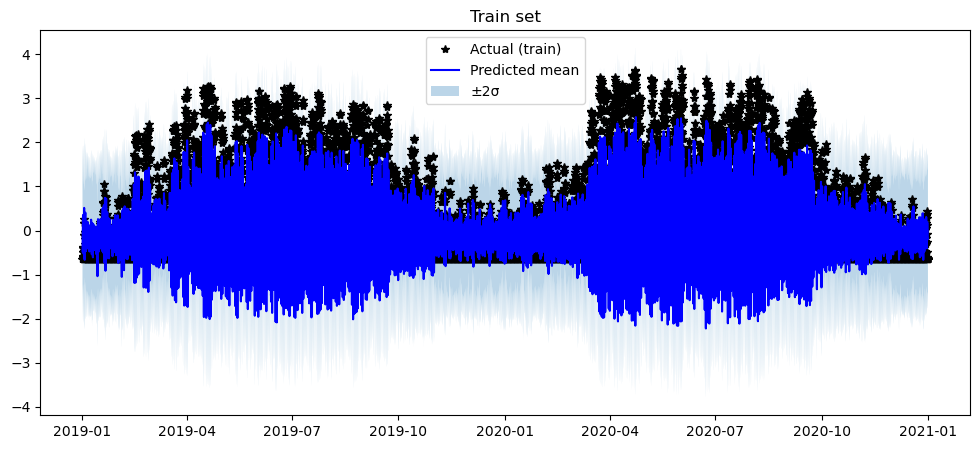

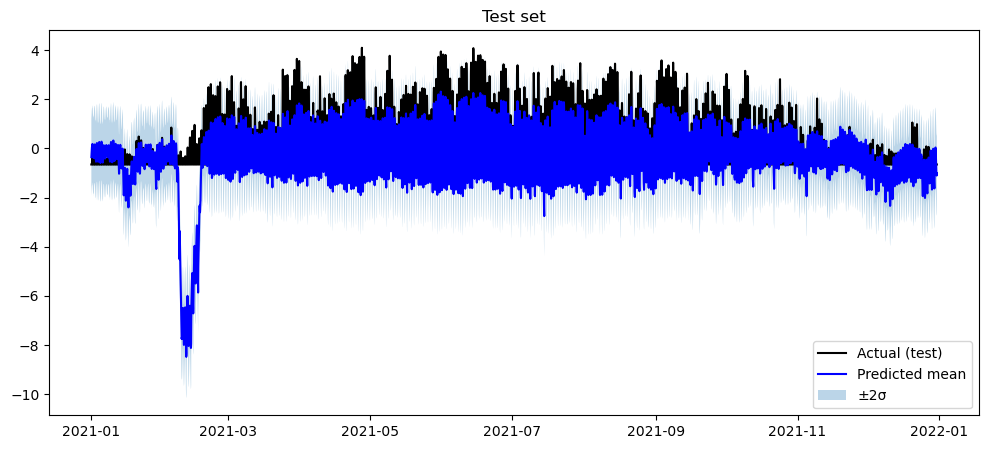

In [43]:
step = 1
mean_tr, std_tr = y_hat_train.mean[:,step].detach().numpy(), y_hat_train.stddev[:,step].detach().numpy()
mean_te, std_te = y_hat_test.mean[:,step].detach().numpy(), y_hat_test.stddev[:,step].detach().numpy()

# Train plot
plt.figure(figsize=(12,5))
plt.plot(dates_train, y_train[:,step], 'k*', label='Actual (train)')
plt.plot(dates_train, mean_tr,     'b',  label='Predicted mean')
plt.fill_between(dates_train,
                 (mean_tr-2*std_tr),
                 (mean_tr+2*std_tr),
                 alpha=0.3, label='±2σ')
plt.title('Train set')
plt.legend()
plt.show()

# Test plot
plt.figure(figsize=(12,5))
plt.plot(dates_test, y_test[:,step], 'k', label='Actual (test)')
plt.plot(dates_test, mean_te,      'b',  label='Predicted mean')
plt.fill_between(dates_test,
                 (mean_te-2*std_te),
                 (mean_te+2*std_te),
                 alpha=0.3, label='±2σ')
plt.title('Test set')
plt.legend()
plt.show()

In [1]:
y_hat_train = y_hat_likelihood_train.mean
rmse_per_horizon_train = torch.sqrt(((y_hat_train - y_train) ** 2).mean(dim=0))  # (24,)

y_hat_test = y_hat_likelihood_test.mean
rmse_per_horizon_test = torch.sqrt(((y_hat_test - y_test) ** 2).mean(dim=0))  # (24,)

NameError: name 'y_hat_likelihood_train' is not defined